In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

base_dir = '/kaggle/input/datasets/sanikamal/rock-paper-scissors-dataset/Rock-Paper-Scissors'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
    validation_split=0.2 
)

test_datagen = ImageDataGenerator(rescale=1./255)

TARGET_SIZE = (150, 150)
BATCH_SIZE = 32

print("--- Đang load tập Training ---")
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training'
)

print("\n--- Đang load tập Validation ---")
val_generator = train_datagen.flow_from_directory(
    train_dir, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation'
)

print("\n--- Đang load tập Test ---")
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

2026-03-19 13:10:11.177126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773925811.382251      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773925811.442587      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773925811.925303      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773925811.925345      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773925811.925347      55 computation_placer.cc:177] computation placer alr

--- Đang load tập Training ---
Found 2016 images belonging to 3 classes.

--- Đang load tập Validation ---
Found 504 images belonging to 3 classes.

--- Đang load tập Test ---
Found 372 images belonging to 3 classes.


In [2]:
model = Sequential([
    Input(shape=(150, 150, 3)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dropout(0.5), 
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    
    Dropout(0.3),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

I0000 00:00:1773925839.019252      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773925839.025302      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,716,227 (44.69 MB)

 Trainable params: 11,713,283 (44.68 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [3]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

weights_dict = {0: 2.0, 1: 1.0, 2: 1.0}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=8, verbose=1, restore_best_weights=True)

print("\n Start training (focus in Paper)...")
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[reduce_lr, early_stop],
    class_weight=weights_dict,
    verbose=1
)


 Start training (focus in Paper)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1773925845.728753     145 service.cc:152] XLA service 0x7ed6bc0193d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773925845.728804     145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773925845.728808     145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773925846.556139     145 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-19 13:10:50.289601: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-19 13:10:50.459995: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/63 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.3203 - loss: 4.0247  

I0000 00:00:1773925856.233974     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 542ms/step - accuracy: 0.5573 - loss: 3.0168 - val_accuracy: 0.3333 - val_loss: 6.1241 - learning_rate: 0.0010
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 350ms/step - accuracy: 0.8695 - loss: 2.1213 - val_accuracy: 0.3333 - val_loss: 5.7703 - learning_rate: 0.0010
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 347ms/step - accuracy: 0.9537 - loss: 1.8495 - val_accuracy: 0.3552 - val_loss: 3.8746 - learning_rate: 0.0010
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 356ms/step - accuracy: 0.9490 - loss: 1.7424 - val_accuracy: 0.5556 - val_loss: 3.0324 - learning_rate: 0.0010
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 354ms/step - accuracy: 0.9714 - loss: 1.5896 - val_accuracy: 0.4444 - val_loss: 3.5125 - learning_rate: 0.0010
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 364ms/step - accuracy: 0.9518 - loss: 1.5782 - val_accuracy: 0.5873 - val_loss: 2.7267 - learning_rate: 0.0010
Epoch 7/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 355ms/step - accuracy: 0.9726 - loss: 1.4132 - val_


--- KẾT QUẢ ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 464ms/step - accuracy: 0.9651 - loss: 0.8109
Test Accuracy: 97.85%

Đã lưu mô hình tại: /kaggle/working/rps_cnn_v2_98pct.keras

Matrix...
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step


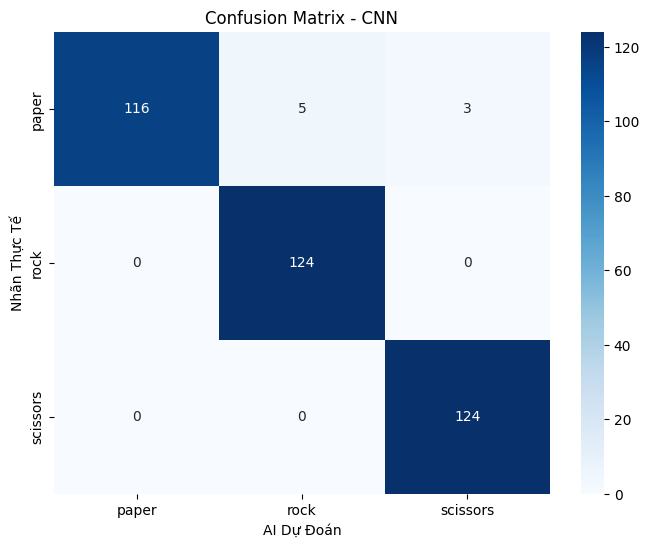


BÁO CÁO CHI TIẾT:
              precision    recall  f1-score   support

       paper       1.00      0.94      0.97       124
        rock       0.96      1.00      0.98       124
    scissors       0.98      1.00      0.99       124

    accuracy                           0.98       372
   macro avg       0.98      0.98      0.98       372
weighted avg       0.98      0.98      0.98       372



In [4]:
print("\n--- KẾT QUẢ ---")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

model_name = f'rps_cnn_v2_{test_accuracy*100:.0f}pct.keras' 
model.save(f'/kaggle/working/{model_name}')
print(f"\nĐã lưu mô hình tại: /kaggle/working/{model_name}")

print("\nMatrix...")
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CNN')
plt.ylabel('Nhãn Thực Tế')
plt.xlabel('AI Dự Đoán')
plt.show()

print("\nBÁO CÁO CHI TIẾT:")
print(classification_report(y_true, y_pred, target_names=class_names))